In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

# Adding for colab

from google.colab import drive
drive.mount('/content/drive')

# Point Python to your specific folder in Drive
# (Change 'Deep_Learning_A2' if you named your Drive folder something else)
os.chdir('/content/drive/MyDrive/DL_PA2/DL_PA2')

Mounted at /content/drive


In [3]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_DIR = './processed_data' # Ensure this matches where you ran make_dataset.py
TRAIN_FILE = os.path.join(DATA_DIR, 'quickdraw_train.npz')
TEST_FILE = os.path.join(DATA_DIR, 'quickdraw_test.npz')

BATCH_SIZE = 128
EPOCHS = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cuda


In [4]:
# ==========================================
# 2. DATASET CLASS (The NPZ Loader)
# ==========================================

class QuickDrawDataset(Dataset):
    def __init__(self, file_path, mode='train'):
        """
        Args:
            file_path (str): Path to the .npz file
            mode (str): 'train' (loads images & labels) or 'test' (loads images only)
        """
        self.mode = mode

        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Could not find file: {file_path}")

        print(f"Loading {mode} data from {file_path}...")
        data = np.load(file_path)

        if mode == 'train':
            # Load x_train and y_train
            self.x = data['x_train']
            self.y = data['y_train']
            self.classes = data['class_names']
            print(f"Loaded {len(self.x)} training samples. Classes: {len(self.classes)}")

        elif mode == 'test':
            # Load test_images (for leaderboard inference)
            self.x = data['test_images']
            self.y = None
            print(f"Loaded {len(self.x)} test images.")

        # Pre-processing:
        # Convert to Float Tensor and Normalize (0-255 -> 0-1)
        self.x = torch.from_numpy(self.x).float() / 255.0

        if self.y is not None:
            self.y = torch.from_numpy(self.y).long()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx]
        if self.mode == 'train':
            label = self.y[idx]
            return img, label
        else:
            return img

In [5]:
# ==========================================
# 3. PREPARE DATALOADERS
# ==========================================

CLASSES = ['apple', 'baseballbat', 'basketball', 'clock', 'compass', 'cookie', 'donut', 'ladder', 'mountain', 'pizza', 'rabbit', 'soccerball', 'spider', 't-shirt', 'wheel']

# 1. Load the Training Data
full_train_dataset = QuickDrawDataset(TRAIN_FILE, mode='train')
NUM_CLASSES = len(full_train_dataset.classes)

# 2. Create Validation Split (80% Train / 20% Val)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# 3. Create Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")

Loading train data from ./processed_data/quickdraw_train.npz...
Loaded 60000 training samples. Classes: 15
Train samples: 48000 | Validation samples: 12000


In [6]:
# ==========================================
# 4. YOUR IMPLEMENTATION HERE
# ==========================================

# A. MODEL DEFINITIONS

class PancakeMLP(nn.Module):
    """
    Part A: The Pancake - Shallow but very wide.
    1 hidden layer with 2048 neurons.
    """
    def __init__(self, input_size=784, num_classes=15):
        super(PancakeMLP, self).__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(input_size, 2048),
            nn.ReLU(),
            nn.Linear(2048, num_classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)

class TowerMLP(nn.Module):
    """
    Part B: The Tower - Deep but narrow.
    5 hidden layers with 256 neurons each.
    """
    def __init__(self, input_size=784, num_classes=15):
        super(TowerMLP, self).__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"PancakeMLP Parameters: {count_parameters(PancakeMLP()):,}")
print(f"TowerMLP Parameters: {count_parameters(TowerMLP()):,}")



def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=EPOCHS, device=DEVICE):
    """
    Trains a PyTorch model and tracks metrics for plotting.
    """
    model.to(device)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = correct_train / total_train

        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc = correct_val / total_val

        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

    return history



PancakeMLP Parameters: 1,638,415
TowerMLP Parameters: 467,983


In [7]:
# THE PANCAKE MODEL
print("Initializing Part A: PancakeMLP...")
model = PancakeMLP().to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Starting training...")
history_pancake = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=EPOCHS,
    device=DEVICE
)
print("Training complete!")

Initializing Part A: PancakeMLP...
Starting training...
Epoch [1/5] | Train Loss: 1.1512 | Train Acc: 0.6295 | Val Loss: 0.9265 | Val Acc: 0.7021
Epoch [2/5] | Train Loss: 0.8255 | Train Acc: 0.7345 | Val Loss: 0.8310 | Val Acc: 0.7395
Epoch [3/5] | Train Loss: 0.6777 | Train Acc: 0.7820 | Val Loss: 0.7865 | Val Acc: 0.7503
Epoch [4/5] | Train Loss: 0.5678 | Train Acc: 0.8175 | Val Loss: 0.7496 | Val Acc: 0.7673
Epoch [5/5] | Train Loss: 0.4699 | Train Acc: 0.8495 | Val Loss: 0.7632 | Val Acc: 0.7664
Training complete!


In [8]:
# THE TOWER MODEL
print("Initializing Part B: TowerMLP...")
tower_model = TowerMLP().to(DEVICE)

tower_criterion = nn.CrossEntropyLoss()

tower_optimizer = optim.Adam(tower_model.parameters(), lr=0.001)

print("Starting training for The Tower...")
history_tower = train_model(
    model=tower_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=tower_criterion,
    optimizer=tower_optimizer,
    epochs=EPOCHS,
    device=DEVICE
)
print("Tower training complete!")

Initializing Part B: TowerMLP...
Starting training for The Tower...
Epoch [1/5] | Train Loss: 1.3645 | Train Acc: 0.5356 | Val Loss: 1.0280 | Val Acc: 0.6607
Epoch [2/5] | Train Loss: 0.9591 | Train Acc: 0.6771 | Val Loss: 0.9439 | Val Acc: 0.6862
Epoch [3/5] | Train Loss: 0.8365 | Train Acc: 0.7195 | Val Loss: 0.8804 | Val Acc: 0.7124
Epoch [4/5] | Train Loss: 0.7472 | Train Acc: 0.7477 | Val Loss: 0.8197 | Val Acc: 0.7197
Epoch [5/5] | Train Loss: 0.6709 | Train Acc: 0.7734 | Val Loss: 0.8001 | Val Acc: 0.7399
Tower training complete!


In [9]:
# THE CHAMPION MODEL (LEADERBOARD)

class ChampionMLP(nn.Module):
    """
    Part C: The Champion - Optimized for the leaderboard.
    Features Batch Normalization and Dropout for regularization.
    """
    def __init__(self, input_size=784, num_classes=15):
        super(ChampionMLP, self).__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(input_size, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)

print(f"ChampionMLP Parameters: {count_parameters(ChampionMLP()):,}")

print("Initializing Part C: ChampionMLP...")
champion_model = ChampionMLP().to(DEVICE)
champion_criterion = nn.CrossEntropyLoss()


champion_optimizer = optim.Adam(champion_model.parameters(), lr=0.0005)

print("Starting training for The Champion...")

history_champion = train_model(
    model=champion_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=champion_criterion,
    optimizer=champion_optimizer,
    epochs=10,
    device=DEVICE
)
print("Champion training complete!")

ChampionMLP Parameters: 1,467,407
Initializing Part C: ChampionMLP...
Starting training for The Champion...
Epoch [1/10] | Train Loss: 1.1508 | Train Acc: 0.6253 | Val Loss: 0.8640 | Val Acc: 0.7116
Epoch [2/10] | Train Loss: 0.8612 | Train Acc: 0.7127 | Val Loss: 0.7849 | Val Acc: 0.7332
Epoch [3/10] | Train Loss: 0.7530 | Train Acc: 0.7469 | Val Loss: 0.7281 | Val Acc: 0.7562
Epoch [4/10] | Train Loss: 0.6828 | Train Acc: 0.7715 | Val Loss: 0.7035 | Val Acc: 0.7666
Epoch [5/10] | Train Loss: 0.6309 | Train Acc: 0.7871 | Val Loss: 0.6822 | Val Acc: 0.7739
Epoch [6/10] | Train Loss: 0.5805 | Train Acc: 0.8049 | Val Loss: 0.6748 | Val Acc: 0.7772
Epoch [7/10] | Train Loss: 0.5424 | Train Acc: 0.8166 | Val Loss: 0.6800 | Val Acc: 0.7789
Epoch [8/10] | Train Loss: 0.5112 | Train Acc: 0.8266 | Val Loss: 0.6782 | Val Acc: 0.7843
Epoch [9/10] | Train Loss: 0.4721 | Train Acc: 0.8415 | Val Loss: 0.6708 | Val Acc: 0.7855
Epoch [10/10] | Train Loss: 0.4491 | Train Acc: 0.8463 | Val Loss: 0.6827

In [10]:
import copy

# ==========================================
# 1. THE UPDATED TRAINING ENGINE (WITH CHECKPOINTING)
# ==========================================
def train_model_advanced(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs, device=DEVICE):
    model.to(device)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}


    best_val_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = correct_train / total_train

        model.eval()
        val_loss, correct_val, total_val = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc = correct_val / total_val

        scheduler.step(epoch_val_loss)


        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Acc: {epoch_train_acc:.4f} | Val Acc: {epoch_val_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f} | LR: {current_lr:.6f}")


    print(f"\nTraining complete. Loading best model weights (Val Acc: {best_val_acc:.4f}).")
    model.load_state_dict(best_model_wts)
    return history



class UltimateMLPV2(nn.Module):
    def __init__(self, input_size=784, num_classes=15):
        super(UltimateMLPV2, self).__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(input_size, 1024),
            nn.BatchNorm1d(1024),
            nn.GELU(),
            nn.Dropout(0.5),

            nn.Linear(1024, 1024),
            nn.BatchNorm1d(1024),
            nn.GELU(),
            nn.Dropout(0.5),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.1),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)

print("\nInitializing Ultimate Champion V2...")
ultimate_model = UltimateMLPV2().to(DEVICE)
ultimate_criterion = nn.CrossEntropyLoss()


ultimate_optimizer = optim.Adam(ultimate_model.parameters(), lr=0.001, weight_decay=1e-4)

ultimate_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    ultimate_optimizer, mode='min', factor=0.5, patience=3
)

print("Starting max-performance training with Checkpointing (40 Epochs)...")
history_ultimate = train_model_advanced(
    model=ultimate_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=ultimate_criterion,
    optimizer=ultimate_optimizer,
    scheduler=ultimate_scheduler,
    epochs=40,
    device=DEVICE
)


Initializing Ultimate Champion V2...
Starting max-performance training with Checkpointing (40 Epochs)...
Epoch [1/40] | Train Acc: 0.6262 | Val Acc: 0.7113 | Val Loss: 0.8634 | LR: 0.001000
Epoch [2/40] | Train Acc: 0.7010 | Val Acc: 0.7422 | Val Loss: 0.7817 | LR: 0.001000
Epoch [3/40] | Train Acc: 0.7244 | Val Acc: 0.7482 | Val Loss: 0.7608 | LR: 0.001000
Epoch [4/40] | Train Acc: 0.7425 | Val Acc: 0.7589 | Val Loss: 0.7248 | LR: 0.001000
Epoch [5/40] | Train Acc: 0.7585 | Val Acc: 0.7718 | Val Loss: 0.6853 | LR: 0.001000
Epoch [6/40] | Train Acc: 0.7696 | Val Acc: 0.7698 | Val Loss: 0.6826 | LR: 0.001000
Epoch [7/40] | Train Acc: 0.7765 | Val Acc: 0.7788 | Val Loss: 0.6631 | LR: 0.001000
Epoch [8/40] | Train Acc: 0.7860 | Val Acc: 0.7822 | Val Loss: 0.6554 | LR: 0.001000
Epoch [9/40] | Train Acc: 0.7929 | Val Acc: 0.7830 | Val Loss: 0.6564 | LR: 0.001000
Epoch [10/40] | Train Acc: 0.7991 | Val Acc: 0.7880 | Val Loss: 0.6520 | LR: 0.001000
Epoch [11/40] | Train Acc: 0.8053 | Val Acc

In [11]:
model = ultimate_model

In [12]:
import pandas as pd
from sklearn.metrics import accuracy_score


print("\n" + "="*40)
print("   GENERATING SUBMISSION FILE")
print("="*40)

test_dataset = QuickDrawDataset(TEST_FILE, mode='test')
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

def get_predictions(model, loader):
    model.eval()
    model.to(DEVICE)
    preds = []
    with torch.no_grad():
        for batch in loader:
            X = batch.to(DEVICE)
            outputs = model(X)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
    return preds


print("Running inference on test set...")
predictions = get_predictions(model, test_loader)


submission_file = "submission.txt"
print(f"Saving predictions to '{submission_file}'...")


submission_string = ",".join(map(str, predictions))

with open(submission_file, "w") as f:
    f.write(submission_string)
print(f"-> Copy & paste the results of this file to the portal.")


   GENERATING SUBMISSION FILE
Loading test data from ./processed_data/quickdraw_test.npz...
Loaded 15000 test images.
Running inference on test set...
Saving predictions to 'submission.txt'...
-> Copy & paste the results of this file to the portal.


In [13]:
def print_model_size(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel Statistics:")
    print(f"  Total Parameters: {total_params:,}")
    if total_params > 3000000:
        print("  ⚠️ WARNING: You are over the 3M parameter limit!")
    else:
        print("  ✅ Parameter count is within limits.")

print_model_size(model)


Model Statistics:
  Total Parameters: 2,519,055
  ✅ Parameter count is within limits.


Generating Validation Predictions for Confusion Matrix...


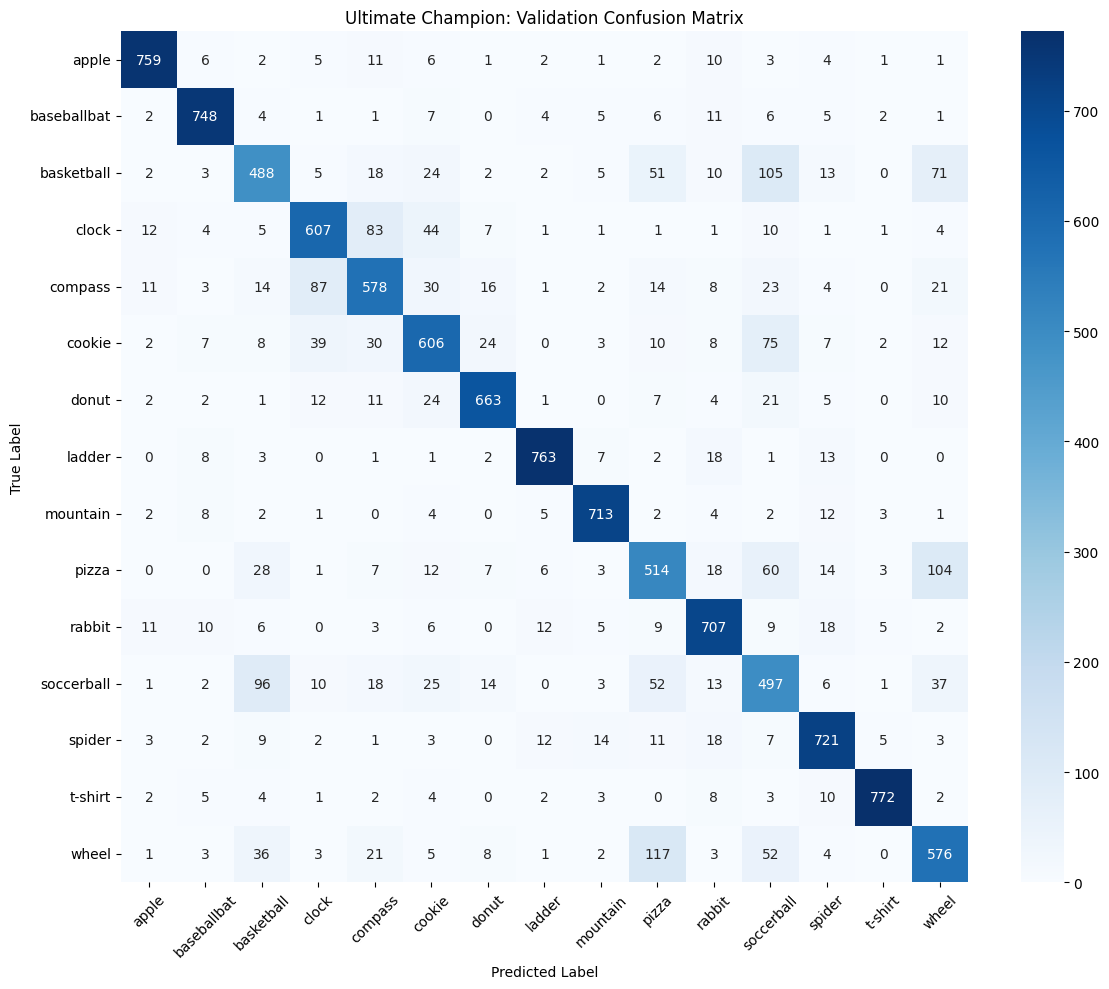


   TOP 2 MOST CONFUSED PAIRS
1. 'wheel' heavily confused with 'pizza' (Occurrences: 117)
2. 'basketball' heavily confused with 'soccerball' (Occurrences: 105)



In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np
import torch

# REPORT ANALYSIS: CONFUSION MATRIX
print("Generating Validation Predictions for Confusion Matrix...")


model.eval()
all_val_preds = []
all_val_labels = []


with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_val_preds.extend(preds.cpu().numpy())
        all_val_labels.extend(labels.cpu().numpy())


cm = confusion_matrix(all_val_labels, all_val_preds)


plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=full_train_dataset.classes,
            yticklabels=full_train_dataset.classes)
plt.title('Ultimate Champion: Validation Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0)


flat_indices = np.argsort(cm_errors.flatten())[::-1]

print("\n" + "="*40)
print("   TOP 2 MOST CONFUSED PAIRS")
print("="*40)
pairs_found = 0
seen_pairs = set()

for idx in flat_indices:
    true_class_idx = idx // len(full_train_dataset.classes)
    pred_class_idx = idx % len(full_train_dataset.classes)

    # Create a frozen set so (A, B) and (B, A) are treated as the same underlying pair
    pair = frozenset([true_class_idx, pred_class_idx])

    if pair not in seen_pairs:
        seen_pairs.add(pair)
        true_name = full_train_dataset.classes[true_class_idx]
        pred_name = full_train_dataset.classes[pred_class_idx]
        count = cm_errors[true_class_idx, pred_class_idx]

        print(f"{pairs_found + 1}. '{true_name}' heavily confused with '{pred_name}' (Occurrences: {count})")
        pairs_found += 1

        if pairs_found == 2:
            break
print("========================================\n")

In [16]:
# Github upload
!git config --global user.email "shujat.504.ali@gmail.com"
!git config --global user.name "shujat-mldl"

In [22]:
%cd /content/drive/MyDrive/DL_PA2/DL_PA2/
!rm -rf temp_repo

/content/drive/MyDrive/DL_PA2/DL_PA2


In [23]:
GIT_TOKEN = "REDACTED"
GIT_USERNAME = "REDACTED"
GIT_REPO = "AI600_PA2"

In [ ]:
!git clone https://{GIT_TOKEN}@github.com/{GIT_USERNAME}/{GIT_REPO}.git temp_repo
!cp 25280086_PA2.ipynb temp_repo/
!cp submission.txt temp_repo/

%cd temp_repo
!git add .
!git commit -m "Final Submission: ChampionMLP V2 (81.33% Accuracy) pushed from Colab"
!git push origin main

Cloning into 'temp_repo'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 9 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), 4.93 KiB | 1.23 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/content/drive/MyDrive/DL_PA2/DL_PA2/temp_repo/temp_repo
[main 6046a44] Final Submission: ChampionMLP V2 (81.33% Accuracy) pushed from Colab
 2 files changed, 2 insertions(+)
 create mode 100644 25280086_PA2.ipynb
 create mode 100644 submission.txt
